# Ситуативная специализация модели Time Machine
У нашей модели не самые впечатляющие показатели точности на классе True (повторная покупка).\
Но есть механизмы, которые позволяют ситуативно увеличивать нужные характеристики модели не переобучая её.

### Механизм перелива между Precision и Recall
Мы можем выделить 4 специализации использования одной и той же модели:

- **Общая**\
  _Цель:_ Предсказание повторной покупки (без временных рамок).\
  _Метрика:_ F1-score (баланс precision/recall).\
  _Применение:_ Общий индикатор лояльности клиентов.

- **Максимизация Precision по классу True**\
  _Цель:_ Максимальная точность (precision) для лояльных клиентов.\
  _Применение:_ Дорогие коммуникации, VIP клиенты, минимизация ложных срабатываний.

- **Максимизация Recall по классу True**\
  _Цель:_ Максимальный охват (recall) лояльных клиентов.\
  _Применение:_ Продажа доп.услуг, рассылки, главное не упустить клиента.

- **Максимизация Precision по классу False**\
  _Цель:_ Точное выявление уходящих клиентов (precision для False)\
  _Применение:_ Сценарии с низкой толерантностью к беспокойству лояльных клиентов (главное не спугнуть).\
  _Пример:_ очень полезно для многих российских компаний, которые злоупотребляют терпением клиентов.

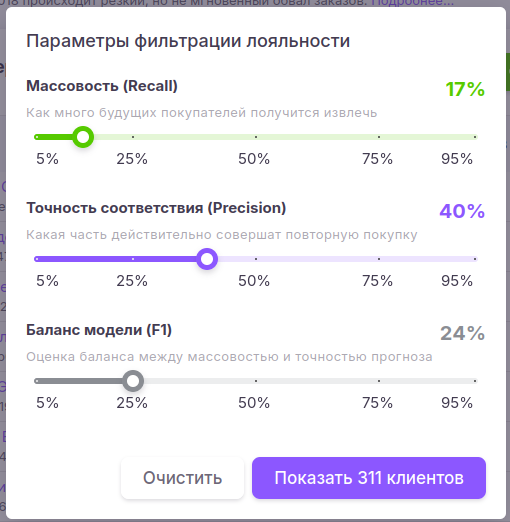

In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from catboost import CatBoostClassifier
from sqlalchemy import create_engine, text
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

print('Необходимые библиотеки загружены.')

Необходимые библиотеки загружены.


In [2]:
# загрузка переменных из .env
load_dotenv()

# получаем токен из окружения
POSTGRES_CONNECTION_URL = os.getenv("POSTGRES_CONNECTION_URL")

try:
    # 1. Загрузка данных
    engine = create_engine(POSTGRES_CONNECTION_URL)

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # engine.dispose()
    print("Connected.")

Connected.


### Загружаем модель

In [3]:
import numpy as np
from catboost import CatBoostClassifier

MODEL_WORK_FILENAME = "TimeMachine pure-base.cbm"

model = CatBoostClassifier()
model.load_model(f"ml-models/{MODEL_WORK_FILENAME}")

about_model_record = pd.read_sql_query(f"SELECT * FROM api_mlmodel where model_file='{MODEL_WORK_FILENAME}'", engine).to_dict('records')[0]
about_model_mean_values = about_model_record['mean_values_json']

### Загрузка обучающих данных
Они нужны нам, чтобы создать матрицу для рассчёта смещения между метриками

In [4]:
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

customer_features = pd.read_sql_query(
  f"""
SELECT
  cft.*,
  cft.days_before_order < 30 as is_customer_will_month,
  srm.*,
  p.*
FROM customer_features_timeline cft
left join orders o on o.order_id ::uuid=cft.order_id 
inner join orders_items oi on oi.order_id =o.order_id
left join seller_retention_metrics srm on srm.seller_id =oi.seller_id
left join products p on p.product_id =oi.product_id
left join product_retention_metrics prm on prm.product_id =oi.product_id
where cft.id is not null""", engine)

In [9]:
print("Test IDs already exist in the database.  Loading from the table.")
test_customer_ids_df = pd.read_sql_query("SELECT customer_unique_id FROM customer_test_ids", engine)
test_customer_ids = test_customer_ids_df['customer_unique_id'].tolist()
if not len(test_customer_ids):
  raise Exception('Таблица тестовых клиентов не заполнена')

Test IDs already exist in the database.  Loading from the table.


### Так же разделяем данные на тестовые и обучающие

In [16]:
# Убедимся, что timeline_date — datetime
customer_features['timeline_date'] = pd.to_datetime(customer_features['timeline_date'])
customer_features['main_payment_type'] = customer_features['main_payment_type'].fillna('not_defined')

# Выбираем дату-разделитель
split_date = pd.to_datetime("2018-02-01")

# Делим по дате и customer_unique_id
train_df = customer_features[
    (~customer_features['customer_unique_id'].isin(test_customer_ids)) &
    (customer_features['timeline_date'] < split_date)
]

test_df = customer_features[
    (customer_features['customer_unique_id'].isin(test_customer_ids)) &
    (customer_features['timeline_date'] >= split_date)
]

# Убираем object/string и нечисловые данные
# Список категориальных признаков, которые НЕ нужно исключать
cat_features = ['main_payment_type']
cols_to_exclude = [
    col for col in train_df.select_dtypes(include=['object', 'string']).columns
    if col not in cat_features
]
train_df = train_df[about_model_record['feature_columns'] + ['is_customer_will_order']]
test_df = test_df[about_model_record['feature_columns'] + ['is_customer_will_order']]

# X и y
drop_cols = ['is_customer_will_order', 'is_customer_will_month', 'days_before_order', 'timeline_date']
X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['is_customer_will_order']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['is_customer_will_order']

# NaN → среднее
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_train.mean(numeric_only=True))  # подгонка под train


### Используем готовую модель для предсказания

In [17]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.96      0.99      0.97      5949
        True       0.36      0.17      0.23       278

    accuracy                           0.95      6227
   macro avg       0.66      0.58      0.60      6227
weighted avg       0.94      0.95      0.94      6227



### Методы для вычисления порога смещения и ожидаемых метрик.

Общий алгоритм:

1. **Сначала мы получаем все возможные пороги** precision_recall_curve() автоматически перебирает ВСЕ возможные пороги от 0 до 1 с мелким шагом и для каждого считает precision/recall.

2. Фильтруем пороги по цели. Поиск ВСЕХ порогов, где метрика (precision/recall/F1) ≥ целевого значения.

3. Логика выбора:
    - Для precision берём первый подходящий порог (valid_indices[0])\
    → Самый консервативный вариант (меньше false positives)
    - Для recall/F1 берём последний подходящий порог (valid_indices[-1])\
    → Максимальный охват (меньше false negatives)

In [53]:
def get_predict_threshold(model, X_val, y_val, target_type='recall', target_value=0.3):
    """
    Определяет смещение по заданной метрике (recall, precision, f1) и её целевому значению.
    """
    # Получаем вероятности для всего X_val
    y_proba_val = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val)

    metric_array = {
        'recall': recall,
        'precision': precision
    }.get(target_type)

    if metric_array is None and target_type == 'f1':
        # f1 считается вручную по каждой паре precision/recall
        metric_array = 2 * (precision * recall) / (precision + recall + 1e-10)

    if metric_array is None:
        raise ValueError("target_type должен быть 'recall', 'precision' или 'f1'")

    # Ищем максимальный threshold при котором метрика ≥ целевой
    valid_indices = np.where(metric_array >= target_value)[0]
    if len(valid_indices) == 0:
        raise ValueError(f"Нет такого порога, при котором {target_type} >= {target_value}")

    best_idx = (
        valid_indices[0] if target_type == 'precision'
        else valid_indices[-1]
    )
    threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

    return float(threshold)

def get_predict_threshold_with_metrics(model, X_val, y_val, target_type='recall', target_value=0.3):
    """
    Определяет оптимальный порог и возвращает ожидаемые метрики.
    
    Возвращает:
        dict: {
            'threshold': float,
            'precision': float,
            'recall': float,
            'f1': float,
            'target_achieved': bool  # Достигнуто ли целевое значение
        }
    """
    # Получаем вероятности
    y_proba_val = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val)
    
    # Рассчитываем F1 для всех порогов
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    # Выбираем целевую метрику
    metric_map = {
        'recall': recall,
        'precision': precision,
        'f1': f1_scores
    }
    
    if target_type not in metric_map:
        raise ValueError("target_type должен быть 'recall', 'precision' или 'f1'")
        
    metric_array = metric_map[target_type]
    
    # Ищем оптимальный порог
    if target_type == 'precision':
        # Для precision берем первый подходящий порог (самый консервативный)
        valid_indices = np.where(metric_array >= target_value)[0]
        best_idx = valid_indices[0] if len(valid_indices) > 0 else -1
    else:
        # Для recall и f1 берем последний подходящий (максимальный охват)
        valid_indices = np.where(metric_array >= target_value)[0]
        best_idx = valid_indices[-1] if len(valid_indices) > 0 else -1
    
    # Формируем результат
    if best_idx == -1:
        # Если целевое значение недостижимо, берем лучший возможный вариант
        best_idx = np.argmax(metric_array)
        target_achieved = False
    else:
        target_achieved = True
    
    threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
    
    return {
        'threshold': float(threshold),
        'precision': float(precision[best_idx]),
        'recall': float(recall[best_idx]),
        'f1': float(f1_scores[best_idx]),
        'target_achieved': target_achieved
    }

def predict_with_target(model, sample, threshold):
    """
    Делает предсказание с учётом смещения по заданной метрике (recall, precision) и её целевому значению.
    """
    # Вероятность и предсказание для одного sample
    proba = model.predict_proba(sample)[0][1]
    pred_class = proba >= threshold

    return {
        'class': bool(pred_class),
        'proba': float(proba),
    }


#### Проверям, как нам удаётся вычислять новые смещение и изменённые метрики

In [52]:
sample = X_test.sample(1)

threshold = get_predict_threshold(
    model=model,
    X_val=X_test,
    y_val=y_test,
    target_type='precision',
    target_value=0.50
)
result = predict_with_target(
    model=model,
    sample=sample,
    threshold=threshold
)

print("Вероятность:", result['proba'])
print("Порог:", threshold)
print("Класс:", result['class'])

Вероятность: 0.03265246006524498
Порог: 0.7064330820394217
Класс: False


In [60]:
print(get_predict_threshold_with_metrics(
    model=model,
    X_val=X_test,
    y_val=y_test,
    target_type='recall',
    # target_type='precision',
    target_value=0.25
))

0.1730948595384394
{'threshold': 0.1730948595384394, 'precision': 0.11006289308176101, 'recall': 0.2517985611510791, 'f1': 0.1531728664784586, 'target_achieved': True}


## Матрица смещений
Каждый раз рассчитывать смещение таким образом, как мы это делали сейчас явно не удобно. Поэтому запишем все значения threshold, precision, recall и f1 в таблицу с шагом 5% и сохраним рядом с моделью.

In [64]:
import json
import numpy as np

recall_options = []
for r in np.arange(0.05, 1.0, 0.05):
    target = round(r, 2)
    result = get_predict_threshold_with_metrics(
        model=model,
        X_val=X_test,
        y_val=y_test,
        target_type='recall',
        target_value=target
    )
    result['target'] = target
    recall_options.append(result)

precision_options = []
for p in np.arange(0.05, 1.0, 0.05):
    target = round(p, 2)
    result = get_predict_threshold_with_metrics(
        model=model,
        X_val=X_test,
        y_val=y_test,
        target_type='precision',
        target_value=target
    )
    result['target'] = target
    precision_options.append(result)

print(json.dumps({
    'recalls': recall_options,
    'precisions': precision_options,
}))

{"recalls": [{"threshold": 0.845931130045252, "precision": 0.7368421052631579, "recall": 0.050359712230215826, "f1": 0.09427609426411816, "target_achieved": true, "target": 0.05}, {"threshold": 0.6333354467673621, "precision": 0.4057971014492754, "recall": 0.10071942446043165, "f1": 0.16138328527073226, "target_achieved": true, "target": 0.1}, {"threshold": 0.565293521690343, "precision": 0.4077669902912621, "recall": 0.1510791366906475, "f1": 0.22047244090543053, "target_achieved": true, "target": 0.15}, {"threshold": 0.32670098725190755, "precision": 0.1978798586572438, "recall": 0.2014388489208633, "f1": 0.1996434937111448, "target_achieved": true, "target": 0.2}, {"threshold": 0.1730948595384394, "precision": 0.11006289308176101, "recall": 0.2517985611510791, "f1": 0.1531728664784586, "target_achieved": true, "target": 0.25}, {"threshold": 0.09652694539898808, "precision": 0.0726643598615917, "recall": 0.302158273381295, "f1": 0.11715481168422512, "target_achieved": true, "target":

## Итог
У нас в руках появился мощный инструмент, который позволит нам компенсировать слабую предсказательную способность модели.\
В интерфейсе сайта, в разделе списка клиентов, можно наглядно убедиться в полезности данной механики.